In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mis_dro.dataset import *
from mis_dro.plot import *
from mis_dro.newsvendor import newsvendor_cost_cvxpy

/tmp/dcs-tmp.u1604520/ipykernel_1201383/3682703318.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [9]:
dgp = "contaminated_normal"

In [10]:
df_list = []
for name in ["cont_normal_9010_mmd", "cont_normal_9010_bas"]:
    df_list.append(pd.read_csv(Path(f"/dcs/pg23/u1604520/misdro/results/opt_results/{name}/results.csv")))
all_results_df = pd.concat(df_list)

In [11]:
all_results_df["num_observations"].unique(), all_results_df["num_posterior_samples"].unique(), all_results_df["num_likelihood_samples"].unique()

(array([20]), array([90,  1]), array([ 10, 900]))

In [12]:
results_df = preprocess_results_df(all_results_df, dgp)
agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "inference", "contamination"]) 
agg_df.head(3)

/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function mean at 0x7f84b873e980> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function std at 0x7f84b873eac0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   dgp                 epsilon inference contamination                       
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                     18.630924   
                                                  0.1                     18.722584   
                                                  0.2                     18.688340   

                                                                 out_of_sample_var  \
algorithm   dgp                 epsilon inference contamination                      
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                   207.095834   
                                                  0.1                   205.761577   
                                                  0.2                   203.618090   

                                                                 sum_of_in_group_var  \
algorithm   dgp                 epsilon inference contamination                        
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                     201.998429   
                                                  0.1                     200.336736   
                                                  0.2                     198.230374   

                                                                 var_of_in_group_mean  \
algorithm   dgp                 epsilon inference contamination                         
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                        5.097405   
                                                  0.1                        5.424841   
                                                  0.2                        5.387716   

                                                                 mean_solve_time  \
algorithm   dgp                 epsilon inference contamination                    
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                 296.047598   
                                                  0.1                 281.196323   
                                                  0.2                 244.941082   

                                                                 std_solve_time  \
algorithm   dgp                 epsilon inference contamination                   
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                  9.340463   
                                                  0.1                 11.132056   
                                                  0.2                 11.226545   

                                                                 mean_sample_time  \
algorithm   dgp                 epsilon inference contamination                     
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                    0.007706   
                                                  0.1                    0.005840   
                                                  0.2                    0.006371   

                                                                 std_sample_time  
algorithm   dgp                 epsilon inference contamination                   
dro_bas_mmd contaminated_normal 0.0001  npl_mmd   0.0                   0.011062  
                                                  0.1                   0.002051  
                                                  0.2                   0.002534

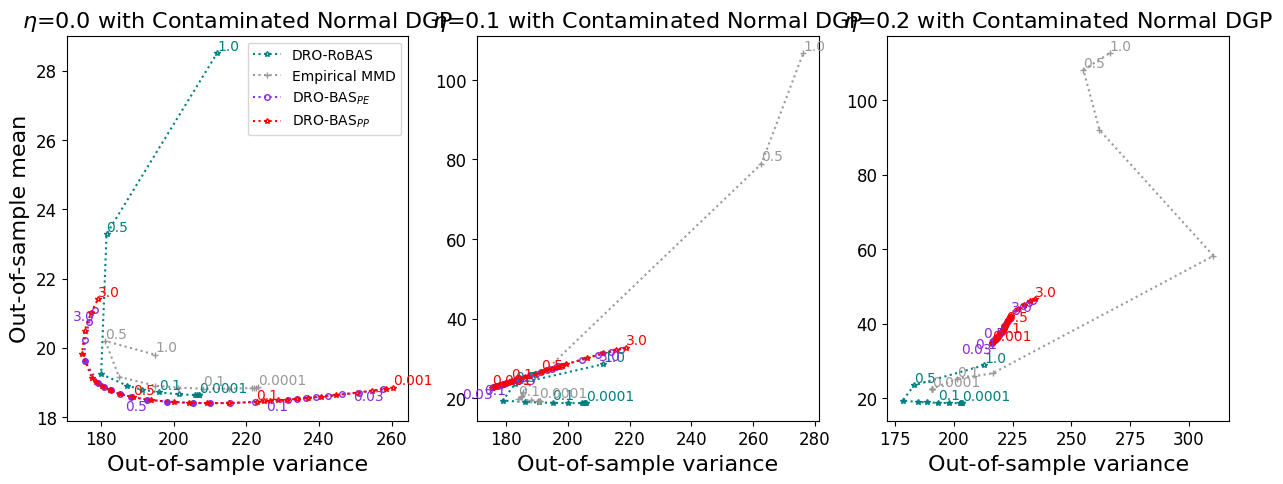

In [15]:
cont_list = agg_df.index.get_level_values("contamination").unique().tolist()
dgp_list = agg_df.index.get_level_values("dgp").unique().tolist()

nrows = len(dgp_list)
ncols = len(cont_list)


fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=False, sharey=False, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.2)
pd.options.mode.chained_assignment = None  # default='warn'
# fig.suptitle('Symmetric newsvendor', fontsize=16)
total_samples = 900
for i, dgp in enumerate(dgp_list):
    for j, cont in enumerate(cont_list):
        axis_df = agg_df.loc[:, dgp, :, :, cont]  
        axis_df.loc[:, "is_pareto_front"] = is_minimise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
        for algorithm in axis_df.index.get_level_values("algorithm").unique():
            if algorithm == 'dro_bas_mmd':
                inference = "npl_mmd"
            elif algorithm in ['kl_bdro', 'kl_dro_bas', 'kl_pp']:
                inference = "bayes"
            else:
                inference = "empirical"
            df = axis_df.loc[algorithm, :, inference]
            alpha = 1.0
            is_labelled=True
            mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha)
        if j == 0:
            axes[j].legend(fontsize=10)
            axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        axes[j].set_title("$\eta$" + f"={cont_list[j]} with {NiceNameDGP[dgp]}", fontsize=16) 
        axes[j].tick_params(axis='both', which='major', labelsize=12)
        axes[j].set_xlabel("Out-of-sample variance", fontsize=16)

In [16]:
solve_time_df = get_agg_df(results_df, ["algorithm", "contamination"])
solve_time_df = solve_time_df.round(decimals=4)
solve_time_df["str_solve_time"] = solve_time_df[["mean_solve_time", "std_solve_time"]].apply(
    lambda x: f"{x['mean_solve_time']} ({x['std_solve_time']})", axis=1
)
solve_time_df["str_sample_time"] = solve_time_df[["mean_sample_time", "std_sample_time"]].apply(
    lambda x: f"{x['mean_sample_time']} ({x['std_sample_time']})", axis=1
)
print(solve_time_df[["str_solve_time", "str_sample_time"]].unstack(level="algorithm").to_latex())

\begin{tabular}{lllllllll}
\toprule
 & \multicolumn{4}{r}{str_solve_time} & \multicolumn{4}{r}{str_sample_time} \\
algorithm & dro_bas_mmd & empirical_mmd & kl_dro_bas & kl_pp & dro_bas_mmd & empirical_mmd & kl_dro_bas & kl_pp \\
contamination &  &  &  &  &  &  &  &  \\
\midrule
0.000000 & 286.2696 (16.1353) & 2.2219 (0.2756) & 0.2911 (0.0404) & 0.2961 (0.0442) & 0.0144 (0.1298) & 0.0 (0.0) & 0.0002 (0.0) & 0.0002 (0.0) \\
0.100000 & 284.6181 (17.4162) & 2.2266 (0.24) & 0.2909 (0.0347) & 0.2959 (0.0386) & 0.0512 (0.5726) & 0.0 (0.0) & 0.0002 (0.0) & 0.0002 (0.0) \\
0.200000 & 260.6738 (35.9001) & 2.1985 (0.235) & 0.284 (0.0331) & 0.2841 (0.0382) & 0.0716 (1.6955) & 0.0 (0.0) & 0.0002 (0.0) & 0.0002 (0.0) \\
\bottomrule
\end{tabular}



/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function mean at 0x7f84b873e980> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/dcs/pg23/u1604520/mis-dro-code/mis_dro/plot.py:196: FutureWarning: The provided callable <function std at 0x7f84b873eac0> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(
